In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
%cd /content/drive/MyDrive/toxic-comments-classification
!ls

/content/drive/MyDrive/toxic-comments-classification
app.py	       data	     models    outputs	  requirements.txt
configuration  history.json  notebook  README.md  src


In [ ]:
!git remote -v

origin	https://github.com/Pasha0923/toxic-comments-classification.git (fetch)
origin	https://github.com/Pasha0923/toxic-comments-classification.git (push)


In [ ]:
!pip install -r requirements.txt

In [ ]:
# Train dataset
!python -m src.train

Loading weights: 100% 201/201 [00:16<00:00, 11.93it/s, Materializing param=classifier.weight]

===== Epoch 1/5 =====
Epoch 1/5: 100% 1000/1000 [06:42<00:00,  2.48it/s]
Train Loss: 0.0278
Validation Loss: 0.0150

Best thresholds:
toxic: 0.55
severe_toxic: 0.45
obscene: 0.50
threat: 0.25
insult: 0.50
identity_hate: 0.35

Classification Report:

               precision    recall  f1-score   support

        toxic       0.77      0.85      0.81       399
 severe_toxic       0.45      0.68      0.54        38
      obscene       0.77      0.85      0.81       218
       threat       0.03      0.17      0.04         6
       insult       0.68      0.82      0.74       204
identity_hate       0.18      0.42      0.25        36

    micro avg       0.66      0.81      0.73       901
    macro avg       0.48      0.63      0.53       901
 weighted avg       0.71      0.81      0.75       901
  samples avg       0.07      0.08      0.07       901

Validation F1: 0.5329
Writing model shards: 100

In [ ]:
from transformers import BertTokenizer,BertForSequenceClassification
#  Load the trained model
model = BertForSequenceClassification.from_pretrained(
    "/content/drive/MyDrive/best_model_v3"
)
tokenizer = BertTokenizer.from_pretrained(
    "/content/drive/MyDrive/best_model_v3"
)


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

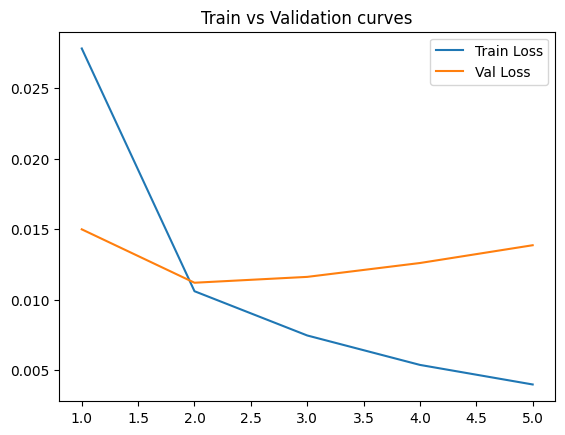

In [ ]:
# Train/Validation Loss
import matplotlib.pyplot as plt
import json

with open("history.json", "r") as f:
    history = json.load(f)

train_losses = history["train_losses"]
val_losses = history["val_losses"]
val_f1 = history["val_f1"]

epochs = range(1, len(train_losses) + 1)

plt.figure()
plt.plot(epochs, train_losses, label="Train Loss")
plt.plot(epochs, val_losses, label="Val Loss")

plt.legend()
plt.title("Train vs Validation curves")
plt.show()

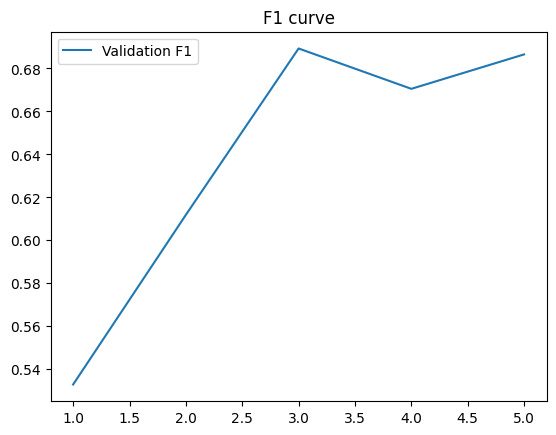

In [ ]:
# F1 validation per epochs
plt.figure()
plt.plot(epochs, val_f1, label="Validation F1")

plt.legend()
plt.title("F1 curve")
plt.show()

In [ ]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from transformers import BertTokenizer, BertForSequenceClassification
from torch.utils.data import DataLoader
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import f1_score
from src.evaluation import find_best_thresholds , evaluate
from src.dataset import ToxicDataset
from src.preprocessing import preprocess_dataframe
from configuration.config import LABEL_COLUMNS , RANDOM_STATE , MAX_LENGTH

In [ ]:
device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)
model.to(device)
model.eval()

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

In [ ]:
# Preprocessing test

# load test data
test = pd.read_csv("data/test.csv")

# load labels
labels = pd.read_csv("data/test_labels.csv")

# merge by id
df_test = test.merge(labels,on="id")

# remove rows with unknown labels (-1)
for col in LABEL_COLUMNS:

    df_test = df_test[df_test[col] != -1]

df_test = preprocess_dataframe(df_test)

X_test = df_test["comment_text"]

y_test = df_test[LABEL_COLUMNS].values

print("Test shape:")
print(df_test.shape)

Test shape:
(63978, 8)


In [ ]:
# create DataLoader for test
from torch.utils.data import DataLoader

test_dataset = ToxicDataset(
    texts=X_test.values,
    labels=y_test,
    tokenizer=tokenizer,
    max_length=MAX_LENGTH
)

test_loader = DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=False
)

In [ ]:
# Final Test Evaluation
BEST_THRESHOLDS = [0.50,0.40,0.50,0.35,0.35,0.60]

test_f1 = evaluate(model,test_loader,device,threshold=BEST_THRESHOLDS)

print(f"\nFinal Test F1: {test_f1:.4f}")


Classification Report:

               precision    recall  f1-score   support

        toxic       0.54      0.87      0.67      6090
 severe_toxic       0.29      0.68      0.40       367
      obscene       0.67      0.76      0.71      3691
       threat       0.43      0.12      0.19       211
       insult       0.51      0.82      0.63      3427
identity_hate       0.67      0.43      0.52       712

    micro avg       0.55      0.79      0.65     14498
    macro avg       0.52      0.61      0.52     14498
 weighted avg       0.56      0.79      0.65     14498
  samples avg       0.07      0.08      0.07     14498


Final Test F1: 0.5207


In [ ]:
# вірогідності моделі(all_probs) , бінарні передбачення(all_preds) і справжні мітки(all_labels) на test для їх подальшого використання
all_probs=[]
all_preds=[]
all_labels=[]
all_texts=[]

model.eval()

with torch.no_grad():

    for batch in test_loader:

        input_ids=batch["input_ids"].to(device)

        attention_mask=batch["attention_mask"].to(device)

        outputs=model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        probs=torch.sigmoid(outputs.logits).cpu().numpy()

        labels=batch["labels"].cpu().numpy()

        preds=(probs>BEST_THRESHOLDS).astype(int)

        all_probs.append(probs)
        all_preds.append(preds)
        all_labels.append(labels)

all_probs=np.vstack(all_probs)
all_preds=np.vstack(all_preds)
all_labels=np.vstack(all_labels)
all_texts=X_test.values

print("Probabilities:",all_probs.shape)
print("Predictions:",all_preds.shape)
print("Labels:",all_labels.shape)

Probabilities: (63978, 6)
Predictions: (63978, 6)
Labels: (63978, 6)


In [ ]:
# save
np.save("outputs/test_probs.npy",all_probs)

np.save("outputs/test_preds.npy",all_preds)

np.save("outputs/test_labels.npy",all_labels)

np.save("outputs/test_texts.npy",np.array(all_texts))

print("Saved successfully")

Saved successfully


In [ ]:
# download
import json
all_probs=np.load("outputs/test_probs.npy")

all_preds=np.load("outputs/test_preds.npy")

all_labels=np.load("outputs/test_labels.npy")

all_texts=np.load("outputs/test_texts.npy",allow_pickle=True)

with open("outputs/thresholds.json","r") as f:
    BEST_THRESHOLDS = json.load(f)

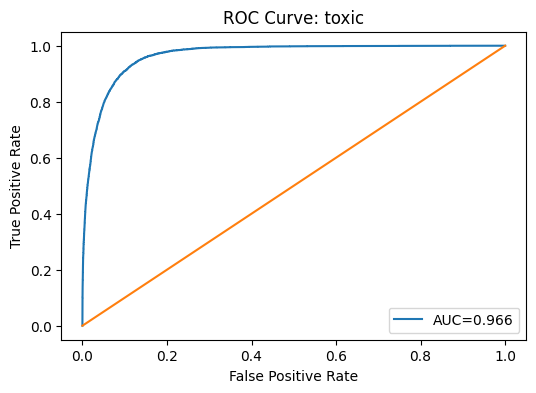

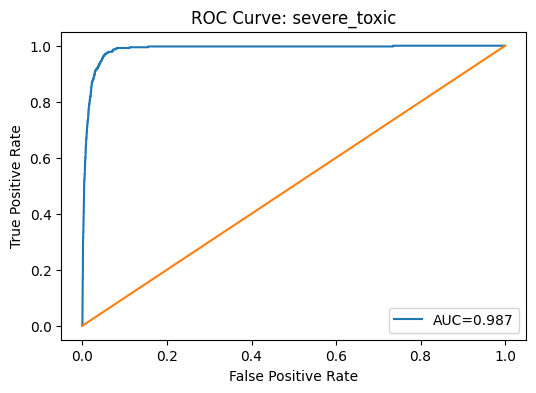

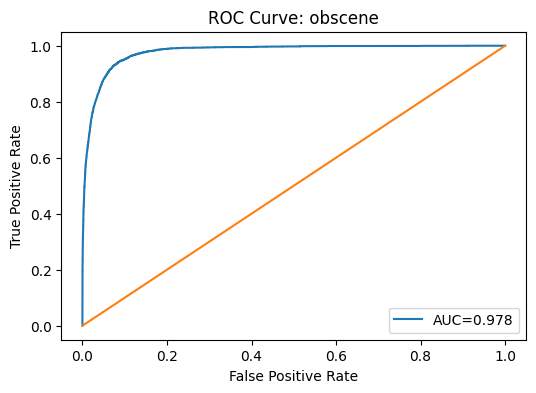

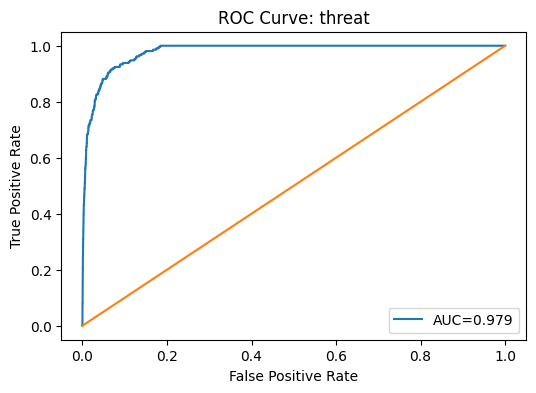

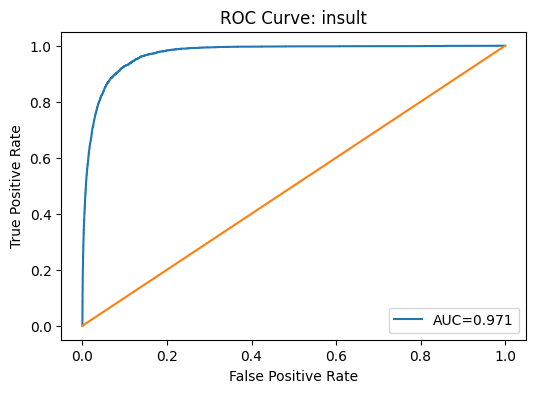

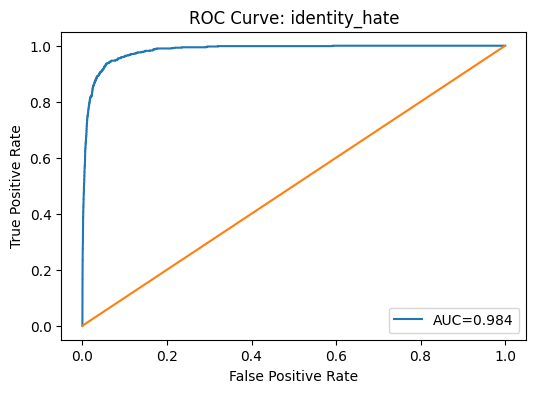

In [ ]:
# ROC-AUC curves per class
from sklearn.metrics import roc_curve
from sklearn.metrics import auc
import matplotlib.pyplot as plt


for i,label in enumerate(LABEL_COLUMNS):

    fpr,tpr,_=roc_curve(
        all_labels[:,i],
        all_probs[:,i]
    )

    roc_auc=auc(fpr,tpr)

    plt.figure(figsize=(6,4))

    plt.plot(fpr,tpr,label=f"AUC={roc_auc:.3f}")

    plt.plot([0,1],[0,1])

    plt.xlabel("False Positive Rate")

    plt.ylabel("True Positive Rate")

    plt.title(f"ROC Curve: {label}")

    plt.legend()

    plt.show()

In [ ]:
# Error analysis: False Positives
for class_id,label in enumerate(LABEL_COLUMNS):

    print(f"\n===== FALSE POSITIVES: {label} =====")

    fp=np.where((all_preds[:,class_id]==1)&(all_labels[:,class_id]==0))[0]

    for idx in fp[:1]:

        print("\nComment:")
        print(all_texts[idx])

In [ ]:
# Error analysis: False Negatives
for class_id,label in enumerate(LABEL_COLUMNS):

    print(f"\n===== FALSE NEGATIVES: {label} =====")

    fn=np.where((all_preds[:,class_id]==0)&(all_labels[:,class_id]==1))[0]

    for idx in fn[:1]:

        print("\nComment:")
        print(all_texts[idx])

In [ ]:
# Example prediction classifier comments

import torch
import pandas as pd

LABEL_NAMES = [

    "toxic",
    "severe_toxic",
    "obscene",
    "threat",
    "insult",
    "identity_hate"
]

texts=[

    "Today a nice day",
    "Cut the bullshit, you are stupid!",
    "Give me a break!Get lost!"
]

inputs=tokenizer(

    texts,
    return_tensors="pt",
    truncation=True,
    padding=True,
    max_length=256
)

inputs={

    k:v.to(device)
    for k,v in inputs.items()
}

model.eval()

with torch.no_grad():

    outputs=model(**inputs)

    probs=torch.sigmoid(
        outputs.logits
    ).cpu().numpy()


for text,p in zip(texts,probs):

    print("="*70)
    print(f"Comment:\n{text}\n")

    results=pd.DataFrame({

        "Class":LABEL_NAMES,
        "Probability (%)":
        (p*100).round(2)

    })

    results=results.sort_values(

        by="Probability (%)",
        ascending=False
    )

    display(results)

Comment:
Today a nice day



,Class,Probability (%)
0,toxic,8.15
4,insult,5.27
2,obscene,5.13
5,identity_hate,4.70
3,threat,4.14
1,severe_toxic,3.12


Comment:
Cut the bullshit, you are stupid!



,Class,Probability (%)
0,toxic,89.889999
2,obscene,84.680000
4,insult,75.239998
1,severe_toxic,41.080002
5,identity_hate,27.299999
3,threat,18.340000


Comment:
Give me a break!Get lost!



,Class,Probability (%)
0,toxic,51.099998
4,insult,21.719999
2,obscene,10.520000
5,identity_hate,7.340000
3,threat,6.230000
1,severe_toxic,4.830000
